In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.api as sm
from sklearn.feature_selection import VarianceThreshold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import StratifiedKFold
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

pd.set_option("mode.copy_on_write", True)

## Load and Pre-process Data

In [2]:
# Load the data
class_df = pd.read_csv("./../cleaned_data/EMA/Class.csv")
behavior = pd.read_csv("./../cleaned_data/EMA/Behaviour_new.csv")
depression = pd.read_csv("./../cleaned_data/surveys/clean_PHQ-9.csv")
grades = pd.read_csv("./../cleaned_data/education/grades.csv")
exercise = pd.read_csv("./../cleaned_data/EMA/Exercise.csv")
mood = pd.read_csv("./../cleaned_data/EMA/Mood.csv")
sleep = pd.read_csv("./../cleaned_data/EMA/Sleep.csv")
social = pd.read_csv("./../cleaned_data/EMA/Social.csv")
stress = pd.read_csv("./../cleaned_data/EMA/Stress.csv")

In [3]:
# Drop unnecessary columns
class_df.drop(columns=["resp_time", "location", "course_id"], inplace=True)
behavior.drop(columns=["resp_time", "datetime_utc"], inplace=True)

# Other cleaning
depression = depression.loc[depression["type"] == "post"]
depression_score = depression[["uid", "total_score"]]
depression_score.rename(
    columns={
        "uid": "user_id",
    },
    inplace=True,
)
grades.rename(
    columns={
        "gpa 13s": "gpa_13s",
        "gpa all": "gpa_all",
        "cs 65": "cs_65",
        "uid": "user_id",
    },
    inplace=True,
)

In [4]:
# Group by user_id and calculate the mean for each user
class_grp = class_df.groupby(["user_id"]).mean()
exercise = exercise[["user_id", "exercise", "walk"]].groupby("user_id").mean()
mood = mood[["user_id", "happy", "happyornot"]].groupby("user_id").mean()
sleep = (
    sleep[["user_id", "sleep_hours", "sleep_quality", "sleepiness"]]
    .groupby("user_id")
    .mean()
)
social = social[["user_id", "number"]].groupby("user_id").mean()
stress = stress[["user_id", "level"]].groupby("user_id").mean()
behavior_grp = behavior.groupby(["user_id"]).mean()

In [5]:
# Merge all dataframes on user_id
merged_behavior = behavior_grp.merge(
    depression_score, on="user_id", how="inner", validate="1:1"
)
merged_grades = merged_behavior.merge(grades, on="user_id", how="inner", validate="1:1")
merged_class = merged_grades.merge(class_grp, on="user_id", how="inner", validate="1:1")
merged_exercise = merged_class.merge(
    exercise, on="user_id", how="inner", validate="1:1"
)
merged_mood = merged_exercise.merge(mood, on="user_id", how="inner", validate="1:1")
merged_sleep = merged_mood.merge(sleep, on="user_id", how="inner", validate="1:1")
merged_stress = merged_sleep.merge(stress, on="user_id", how="inner", validate="1:1")
merged_final = merged_stress.merge(social, on="user_id", how="inner", validate="1:1")

display(merged_final.head())

,user_id,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,...,hours,exercise,walk,happy,happyornot,sleep_hours,sleep_quality,sleepiness,level,number
0,u01,1.000000,5.000000,5.00,1.000000,3.000000,2.00,3.000000,3.000000,5.0,...,2.133333,1.000000,2.428571,2.000000,1.000000,7.222222,1.592593,1.851852,2.250000,3.500000
1,u02,1.500000,4.500000,2.50,2.500000,2.500000,2.00,5.000000,3.000000,2.0,...,4.333333,2.000000,2.416667,1.000000,2.000000,7.923077,2.000000,1.384615,2.066667,2.800000
2,u04,3.500000,2.500000,3.25,3.500000,3.000000,2.75,3.000000,3.000000,3.5,...,3.272727,4.083333,2.583333,1.750000,1.000000,6.470588,2.058824,1.000000,1.860465,3.074074
3,u07,2.076923,3.846154,3.00,1.846154,3.076923,1.00,3.384615,2.923077,4.0,...,3.480000,2.384615,2.307692,1.000000,1.000000,7.041667,2.000000,1.041667,3.245283,3.250000
4,u10,2.000000,3.000000,2.00,3.600000,3.400000,2.20,3.200000,2.400000,3.4,...,3.777778,1.700000,2.100000,1.333333,1.555556,7.787234,2.106383,1.191489,2.396226,3.133333


## Feature Selection

In [6]:
# Remove low-variance features and prepare feature/target matrices
selector = VarianceThreshold(threshold=0.1)
selector.fit_transform(merged_final.loc[:, merged_final.columns != "user_id"])

y = merged_final["total_score"]
X = merged_final.drop(columns=["total_score"])
X["user_id"] = X["user_id"].replace("[^0-9]", "", regex=True).astype("int64")

display(X.head())

,user_id,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,...,hours,exercise,walk,happy,happyornot,sleep_hours,sleep_quality,sleepiness,level,number
0,1,1.000000,5.000000,5.00,1.000000,3.000000,2.00,3.000000,3.000000,5.0,...,2.133333,1.000000,2.428571,2.000000,1.000000,7.222222,1.592593,1.851852,2.250000,3.500000
1,2,1.500000,4.500000,2.50,2.500000,2.500000,2.00,5.000000,3.000000,2.0,...,4.333333,2.000000,2.416667,1.000000,2.000000,7.923077,2.000000,1.384615,2.066667,2.800000
2,4,3.500000,2.500000,3.25,3.500000,3.000000,2.75,3.000000,3.000000,3.5,...,3.272727,4.083333,2.583333,1.750000,1.000000,6.470588,2.058824,1.000000,1.860465,3.074074
3,7,2.076923,3.846154,3.00,1.846154,3.076923,1.00,3.384615,2.923077,4.0,...,3.480000,2.384615,2.307692,1.000000,1.000000,7.041667,2.000000,1.041667,3.245283,3.250000
4,10,2.000000,3.000000,2.00,3.600000,3.400000,2.20,3.200000,2.400000,3.4,...,3.777778,1.700000,2.100000,1.333333,1.555556,7.787234,2.106383,1.191489,2.396226,3.133333


In [7]:
# Evaluate each feature individually by fitting a simple linear regression against the target

function_dict = {"predictor": [], "r-squared": []}

# Iterate through all features in X
for col in X.columns:
    # Use the current feature as the sole predictor
    selected_X = X[[col]]

    # Fit a simple linear regression model: target ~ selected feature
    model = sm.OLS(y, sm.add_constant(selected_X)).fit()

    # Generate predictions
    y_preds = model.predict(sm.add_constant(selected_X))

    # Record the predictor name
    function_dict["predictor"].append(col)

    # Calculate and record R-squared value
    r2 = np.corrcoef(y, y_preds)[0, 1] ** 2
    function_dict["r-squared"].append(r2)

# Convert results to a DataFrame and sort by highest R-squared
function_df = pd.DataFrame(function_dict).sort_values(by="r-squared", ascending=False)


display(function_df.head(5))

,predictor,r-squared
11,gpa_all,0.304158
1,anxious,0.263567
12,gpa_13s,0.169195
21,sleep_hours,0.152217
9,reserved,0.139790


In [8]:
def next_possible_feature(X_npf, y_npf, current_features, ignore_features=[]):
    """
    Evaluate the impact of adding each remaining feature to the current model by R-squared.

    Parameters:
    X_npf           -- Feature matrix (DataFrame)
    y_npf           -- Target variable (Series or array)
    current_features -- List of features currently in the model
    ignore_features  -- List of features to skip

    Returns:
    A DataFrame sorted by R-squared showing the best next features to add.
    """
    function_dict = {"predictor": [], "r-squared": []}

    for col in X_npf.columns:
        # Skip already selected or ignored features
        if col not in current_features + ignore_features:
            # Fit model using current features plus the new candidate
            selected_X = X_npf[current_features + [col]]
            model = sm.OLS(y_npf, sm.add_constant(selected_X)).fit()
            y_preds = model.predict(sm.add_constant(selected_X))

            # Record predictor name and R-squared value
            function_dict["predictor"].append(col)
            r2 = np.corrcoef(y_npf, y_preds)[0, 1] ** 2
            function_dict["r-squared"].append(r2)

    function_df = pd.DataFrame(function_dict).sort_values(
        by="r-squared", ascending=False
    )
    return function_df


# Example usage:
next_possible_feature(X, y, current_features=["gpa_all"], ignore_features=["user_id"])

,predictor,r-squared
14,hours,0.523644
7,experiences,0.468126
2,conventional,0.463263
20,sleep_quality,0.459848
19,sleep_hours,0.452134
0,anxious,0.427455
17,happy,0.399266
18,happyornot,0.391369
21,sleepiness,0.379888
22,level,0.373553


## VIF Calculations

In [9]:
# Create a DataFrame with only the selected features
X_2 = X[["gpa_all", "disorganized"]]

# Initialize the VIF DataFrame
vif_2 = pd.DataFrame()
vif_2["features"] = X_2.columns

# Calculate VIF scores for each feature
vif_2["VIF"] = [variance_inflation_factor(X_2.values, i) for i in range(X_2.shape[1])]

display(vif_2)

,features,VIF
0,gpa_all,6.324483
1,disorganized,6.324483


In [10]:
# Create a DataFrame with the selected features
X_3 = X[["anxious", "gpa_all", "cs_65", "due", "sleep_quality"]]

# Initialize the VIF results DataFrame
vif_3 = pd.DataFrame()
vif_3["features"] = X_3.columns

# Calculate VIF for each feature
vif_3["VIF"] = [variance_inflation_factor(X_3.values, i) for i in range(X_3.shape[1])]

display(vif_3)

,features,VIF
0,anxious,16.937329
1,gpa_all,79.169550
2,cs_65,40.771196
3,due,60.637951
4,sleep_quality,51.093429


## Recursive Feature Elimination

In [11]:
# Initialize linear regression model
lin_model = LinearRegression()

# Apply Recursive Feature Elimination to select top 5 features
rfe = RFE(estimator=lin_model, n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X, y)

# Display the selected feature names
print("Selected features:", X.columns[rfe.get_support()])

Selected features: Index(['anxious', 'gpa_all', 'cs_65', 'exercise', 'sleepiness'], dtype='object')


## Correlation Matrix

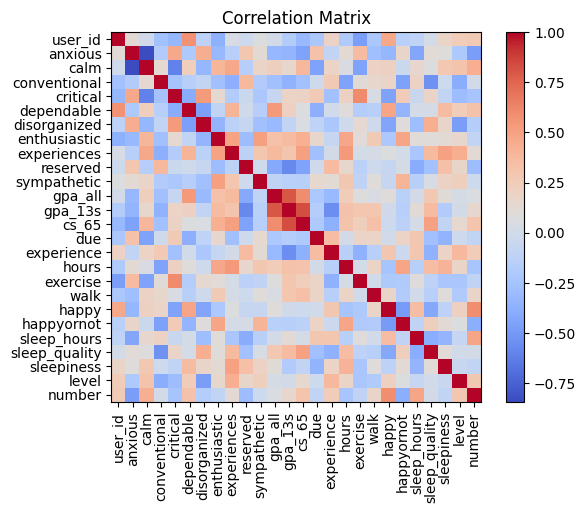

In [12]:
plt.imshow(X.corr(), cmap="coolwarm", interpolation="nearest")
variables = []
for i in X.corr().columns:
    variables.append(i)

plt.xticks(range(len(variables)), variables, rotation=90)
plt.yticks(range(len(variables)), variables)
plt.title("Correlation Matrix")

plt.colorbar()
plt.show()

## Linear Regression

In [13]:
selected_features = [
    "gpa_all",
    "hours",
    "sleep_hours",
    "walk",
    "cs_65",
    "anxious",
    "exercise",
]
features_ignore = ["user_id"]

next_possible_feature(X, y, selected_features, features_ignore)

,predictor,r-squared
14,sleep_quality,0.780613
16,level,0.763509
0,calm,0.762627
6,experiences,0.759234
4,disorganized,0.758807
2,critical,0.757910
3,dependable,0.757068
8,sympathetic,0.756190
15,sleepiness,0.755612
10,due,0.751234


In [14]:
shortened_X = X[
    [
        "gpa_all",
        "hours",
        "sleep_hours",
        "walk",
        "cs_65",
        "anxious",
        "exercise",
    ]
]
shortened_X.columns = range(len(shortened_X.columns))
shortened_X

,0,1,2,3,4,5,6
0,2.863,2.133333,7.222222,2.428571,3.000000,1.000000,1.000000
1,3.505,4.333333,7.923077,2.416667,4.000000,1.500000,2.000000
2,3.029,3.272727,6.470588,2.583333,4.000000,3.500000,4.083333
3,3.474,3.480000,7.041667,2.307692,4.000000,2.076923,2.384615
4,3.667,3.777778,7.787234,2.100000,4.000000,2.000000,1.700000
5,3.293,3.608696,6.966667,3.750000,3.666667,1.000000,1.000000
6,3.373,5.000000,7.907692,2.578947,4.000000,2.333333,1.868421
7,3.476,7.125000,4.900000,2.666667,4.000000,3.272727,1.190476
8,3.474,2.280000,5.909091,2.400000,3.333333,3.000000,2.600000
9,3.947,4.750000,7.836364,2.340909,3.333333,2.377778,2.772727


## Misc Model

In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
)


# Define binary PHQ-9 labels
def binarize_phq9(scores):
    return np.where(scores >= 10, 1, 0)


# Use full dataset without resampling
y_binary = binarize_phq9(y)

# Cross-validation setup
n_splits = 3
folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Metrics storage
mae_list = []
r2_list = []
precision_list = []
recall_list = []
f1_list = []

# Cross-validation loop
for train_idx, test_idx in folds.split(shortened_X, y_binary):
    X_train, X_test = shortened_X.iloc[train_idx], shortened_X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    regressor = LinearRegression()
    regressor.fit(X_train, y_train)

    y_pred_scores = regressor.predict(X_test)

    # Regression metrics
    mae_list.append(mean_absolute_error(y_test, y_pred_scores))
    r2_list.append(r2_score(y_test, y_pred_scores))

    # Classification metrics
    y_test_bin = binarize_phq9(y_test)
    y_pred_bin = binarize_phq9(y_pred_scores)

    precision_list.append(precision_score(y_test_bin, y_pred_bin, pos_label=1))
    recall_list.append(recall_score(y_test_bin, y_pred_bin, pos_label=1))
    f1_list.append(f1_score(y_test_bin, y_pred_bin, pos_label=1))

# Final average results
print("\nBaseline Model - Averaged Results Across Folds:")
print(f"MAE: {np.mean(mae_list):.3f}")
print(f"R2: {np.mean(r2_list):.3f}")
print(f"Precision (Moderate+): {np.mean(precision_list):.3f}")
print(f"Recall (Moderate+): {np.mean(recall_list):.3f}")
print(f"F1 Score (Moderate+): {np.mean(f1_list):.3f}")


Baseline Model - Averaged Results Across Folds:
MAE: 9.139
R2: -7.298
Precision (Moderate+): 0.472
Recall (Moderate+): 1.000
F1 Score (Moderate+): 0.622


In [16]:
# Fit an OLS model using selected predictors on the full dataset
model = ols(
    "total_score ~ gpa_all + hours + sleep_hours + walk + cs_65 + anxious + exercise + sleep_quality",
    data=merged_final,
).fit()

# Display the full model summary
model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1806: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            total_score   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     4.448
Date:                Tue, 22 Apr 2025   Prob (F-statistic):             0.0156
Time:                        12:38:59   Log-Likelihood:                -46.409
No. Observations:                  19   AIC:                             110.8
Df Residuals:                      10   BIC:                             119.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        42.6479     18.446      2.312      0.043       1.548      83.747
gpa_all         -11.3797      2.850     -3.992      0.003     -17.731      -5.029
hours             1.6078      0.917      1.754      0.110      -0.435       3.651
sleep_hours      -0.9650      1.277     -0.756      0.467      -3.810       1.880
walk             -3.6907      2.207     -1.672      0.125      -8.609       1.228
cs_65             6.0546      2.849      2.125      0.059      -0.293      12.402
anxious           5.5492      2.741      2.025      0.070      -0.558      11.656
exercise         -4.1440      2.186     -1.896      0.087      -9.015       0.727
sleep_quality    -6.3448      5.052     -1.256      0.238     -17.601       4.912
==============================================================================
Omnibus:                        5.388   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.068   Jarque-Bera (JB):                3.285
Skew:                           0.984   Prob(JB):                        0.194
Kurtosis:                       3.528   Cond. No.                         217.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Model: Full Data

In [17]:
# Fit model on full data (imbalanced)
ols_model = ols(
    "total_score ~ gpa_all + hours + sleep_hours + walk + cs_65 + anxious + exercise + sleep_quality",
    data=merged_final,
).fit()

# Predict and binarize
y_true = merged_final["total_score"]
y_pred = ols_model.predict(merged_final)

y_true_binary = (y_true >= 10).astype(int)
y_pred_binary = (y_pred >= 10).astype(int)

## Undersampling

In [18]:
# Binarize labels for sampling
merged_final["binary_score"] = (merged_final["total_score"] >= 10).astype(int)

X = merged_final[
    [
        "gpa_all",
        "hours",
        "sleep_hours",
        "walk",
        "cs_65",
        "anxious",
        "exercise",
        "sleep_quality",
    ]
]
y_bin = merged_final["binary_score"]
y_cont = merged_final["total_score"]

# Undersample
rus = RandomUnderSampler(random_state=42)
X_res, y_bin_res = rus.fit_resample(X, y_bin)
y_cont_res = y_cont.iloc[rus.sample_indices_]

# Recombine for statsmodels
df_under = X_res.copy()
df_under["total_score"] = y_cont_res

# Fit OLS
ols_model_under = ols(
    "total_score ~ gpa_all + hours + sleep_hours + walk + cs_65 + anxious + exercise + sleep_quality",
    data=df_under,
).fit()

# Predict on full data to compare performance
y_pred_under = ols_model_under.predict(merged_final)
y_pred_binary_under = (y_pred_under >= 10).astype(int)

## Oversampling

In [19]:
# Oversample the minority class
ros = RandomOverSampler(random_state=42)
X_res, y_bin_res = ros.fit_resample(X, y_bin)

# Get corresponding continuous target values using iloc
y_cont_res = y_cont.iloc[ros.sample_indices_].reset_index(drop=True)

# Recombine with X_res
df_over = X_res.reset_index(drop=True).copy()
df_over["total_score"] = y_cont_res

# Fit OLS
ols_model_over = ols(
    "total_score ~ gpa_all + hours + sleep_hours + walk + cs_65 + anxious + exercise + sleep_quality",
    data=df_over,
).fit()

# Predict on full data
y_pred_over = ols_model_over.predict(merged_final)
y_pred_binary_over = (y_pred_over >= 10).astype(int)

In [20]:
# Evaluate Base
print("Baseline OLS Classification Report:")
print(
    classification_report(
        y_true_binary, y_pred_binary, target_names=["None/Mild", "Moderate+"]
    )
)
print("Confusion Matrix:\n", confusion_matrix(y_true_binary, y_pred_binary))


# Evaluate Undersampling
print("Undersampled OLS Classification Report:")
print(
    classification_report(
        y_true_binary, y_pred_binary_under, target_names=["None/Mild", "Moderate+"]
    )
)
print("Confusion Matrix:\n", confusion_matrix(y_true_binary, y_pred_binary_under))


# Evaluate Oversampling
print("Oversampled OLS Classification Report:")
print(
    classification_report(
        y_true_binary, y_pred_binary_over, target_names=["None/Mild", "Moderate+"]
    )
)
print("Confusion Matrix:\n", confusion_matrix(y_true_binary, y_pred_binary_over))

Baseline OLS Classification Report:
              precision    recall  f1-score   support

   None/Mild       0.93      0.93      0.93        14
   Moderate+       0.80      0.80      0.80         5

    accuracy                           0.89        19
   macro avg       0.86      0.86      0.86        19
weighted avg       0.89      0.89      0.89        19

Confusion Matrix:
 [[13  1]
 [ 1  4]]
Undersampled OLS Classification Report:
              precision    recall  f1-score   support

   None/Mild       1.00      0.86      0.92        14
   Moderate+       0.71      1.00      0.83         5

    accuracy                           0.89        19
   macro avg       0.86      0.93      0.88        19
weighted avg       0.92      0.89      0.90        19

Confusion Matrix:
 [[12  2]
 [ 0  5]]
Oversampled OLS Classification Report:
              precision    recall  f1-score   support

   None/Mild       0.92      0.79      0.85        14
   Moderate+       0.57      0.80      0.67   

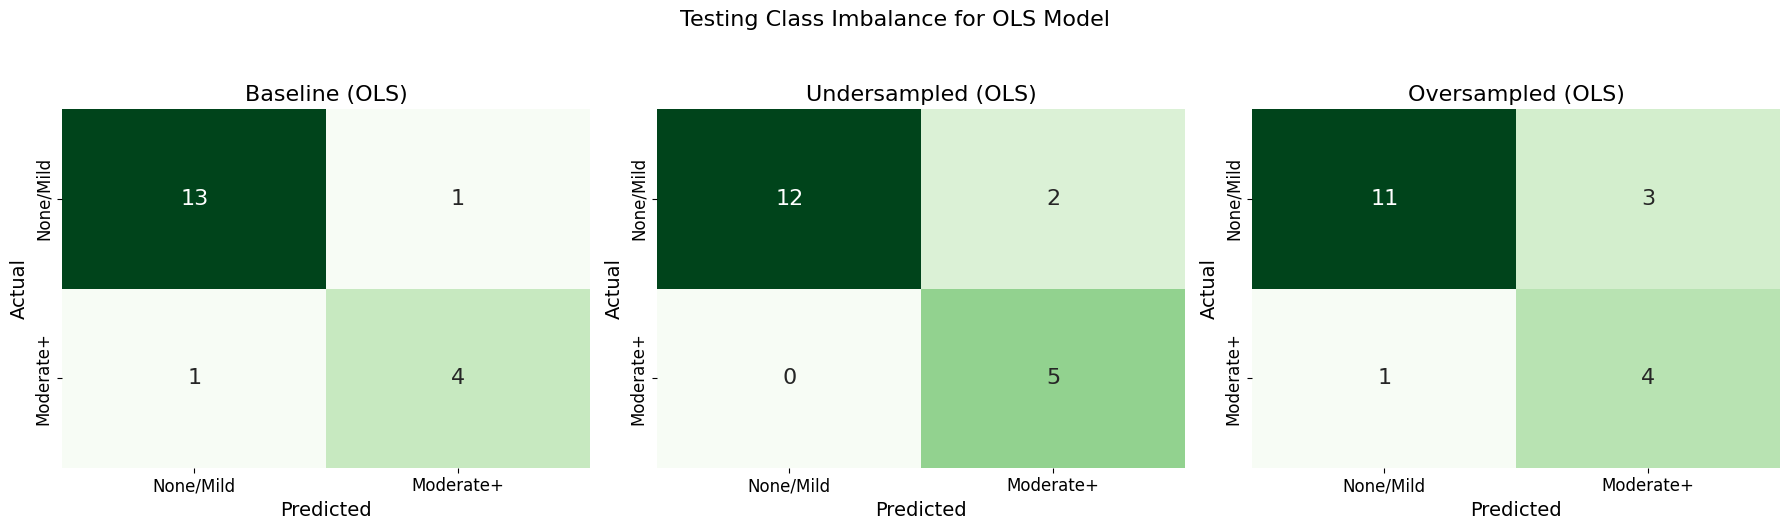

In [21]:
# Confusion matrices for OLS
cm_ols_baseline = confusion_matrix(y_true_binary, y_pred_binary)
cm_ols_under = confusion_matrix(y_true_binary, y_pred_binary_under)
cm_ols_over = confusion_matrix(y_true_binary, y_pred_binary_over)

# Labels
labels = ["None/Mild", "Moderate+"]

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ["Baseline (OLS)", "Undersampled (OLS)", "Oversampled (OLS)"]
cms = [cm_ols_baseline, cm_ols_under, cm_ols_over]

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        annot_kws={"size": 16},
        cbar=False,
    )
    ax.set_xlabel("Predicted", fontsize=14)
    ax.set_ylabel("Actual", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=12)

plt.suptitle("Testing Class Imbalance for OLS Model", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()